In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

**Table of Contents**<a id='toc0_'></a>    
- 1. [Simulation Data Preparation](#toc1_)    
  - 1.1. [Dataset Introduction](#toc1_1_)    
  - 1.2. [Exploratory Data Analysis (EDA)](#toc1_2_)    
    - 1.2.1. [Distribution Analysis](#toc1_2_1_)    
    - 1.2.2. [Linear Correlation Analysis](#toc1_2_2_)    
    - 1.2.3. [Closer Look at Correlation and CEP Method](#toc1_2_3_)    
- 2. [Preprocessing and Splitting](#toc2_)    
  - 2.1. [Train-Test Split (Avoiding Leakage)](#toc2_1_)    
  - 2.2. [Preprocessing & Capacity Estimation Polynomial (CEP) Method](#toc2_2_)    
  - 2.3. [Evaluation & K-Fold Training Wrappers](#toc2_3_)    
  - 2.4. [Optuna Tuning Wrapper](#toc2_4_)    
- 3. [Model Training & Hyperparameter Tuning](#toc3_)    
  - 3.1. [Random Forest Regressor](#toc3_1_)    
  - 3.2. [XGBoost Regressor](#toc3_2_)    
  - 3.3. [Support Vector Regressor (SVR)](#toc3_3_)    
  - 3.4. [AdaBoost Regressor](#toc3_4_)    
- 4. [Model Analysis](#toc4_)    
  - 4.1. [SHAP Analysis](#toc4_1_)    
  - 4.2. [Generalization Testing on Fe@C Composites](#toc4_2_)    
  - 4.3. [Material Screening & Sweet Spot Discovery (Exhaustive Method)](#toc4_3_)

# 1. <a id='toc1_'></a>[Simulation Data Preparation](#toc0_)

## 1.1. <a id='toc1_1_'></a>[Dataset Introduction](#toc0_)

The dataset includes:
- **Features**:
  - **Antimony Content (AC)**: Ratio of Antimony in the Sb@C composite.
  - **Antimony Size (AS)**: Particle size of Antimony (Sb) in nm.
  - **Raman Peak (RP)**: Raman intensity ratio ($I_D/I_G$). Reflects the defect density and graphitization degree of carbon.
  - **Interplanar Spacing (IS)**: Spacing between crystal planes (d-spacing) in nm.
  - **Nitrogen (N)**: Binary indicator (0/1) for nitrogen doping.
  - **Initial Capacity (IC)**: Measured initial discharge capacity in mAh/g.
  - **Degree of Crystallinity (DC)**: Carbon structural crystallinity.
- **Target**:
  - **Remaining Capacity (RC)**: Remaining capacity after 100 cycles in mAh/g.
- **Metadata**:
  - **DOI**: Source publication identifier.

In [4]:
data = pd.read_csv('./input/Sb@C-main.csv')
data = data.drop(columns=["DOI"])

full_name = {
    'AC': 'Antimony Content',
    'AS': 'Antimony Size',
    'RP': 'Raman Peak',
    'IS': 'Interplanar Spacing',
    'N': 'Nitrogen',
    'DC': 'Degree of Crystallinity',
    'IC': 'Initial Capacity',
    'RC': 'Remain Capacity'
}

# Split into X and y
X = data[['AC', 'AS', 'RP', 'IS', 'N', 'IC', 'DC']]
y = data['RC']

data.head()

,AS,IS,DC,RP,N,AC,IC,RC
0,7.5,0.215,3.50,1.31,1,0.070,460.00,362.0
1,30.0,0.310,1.67,0.72,0,0.550,329.94,401.0
2,NaN,0.310,3.46,NaN,0,0.748,430.00,380.0
3,10.0,0.225,2.62,0.97,1,0.790,471.00,405.0
4,30.0,0.310,4.28,1.08,1,0.350,560.00,543.0


## 1.2. <a id='toc1_2_'></a>[Exploratory Data Analysis (EDA)](#toc0_)
**Comments:**
- The dataset is very small, consisting of only 90 samples, which makes imputation choice critical.
- Every feature has some missing values (NaN) that need to be handled.
- Antimony Content (AC) and Initial Capacity (IC) are heavily correlated with Remaining Capacity (RC).
- The Capacity Estimation Polynomial (CEP) method will be used to interpolate missing IC values from AC values using a polynomial curve fit.

### 1.2.1. <a id='toc1_2_1_'></a>[Distribution Analysis](#toc0_)

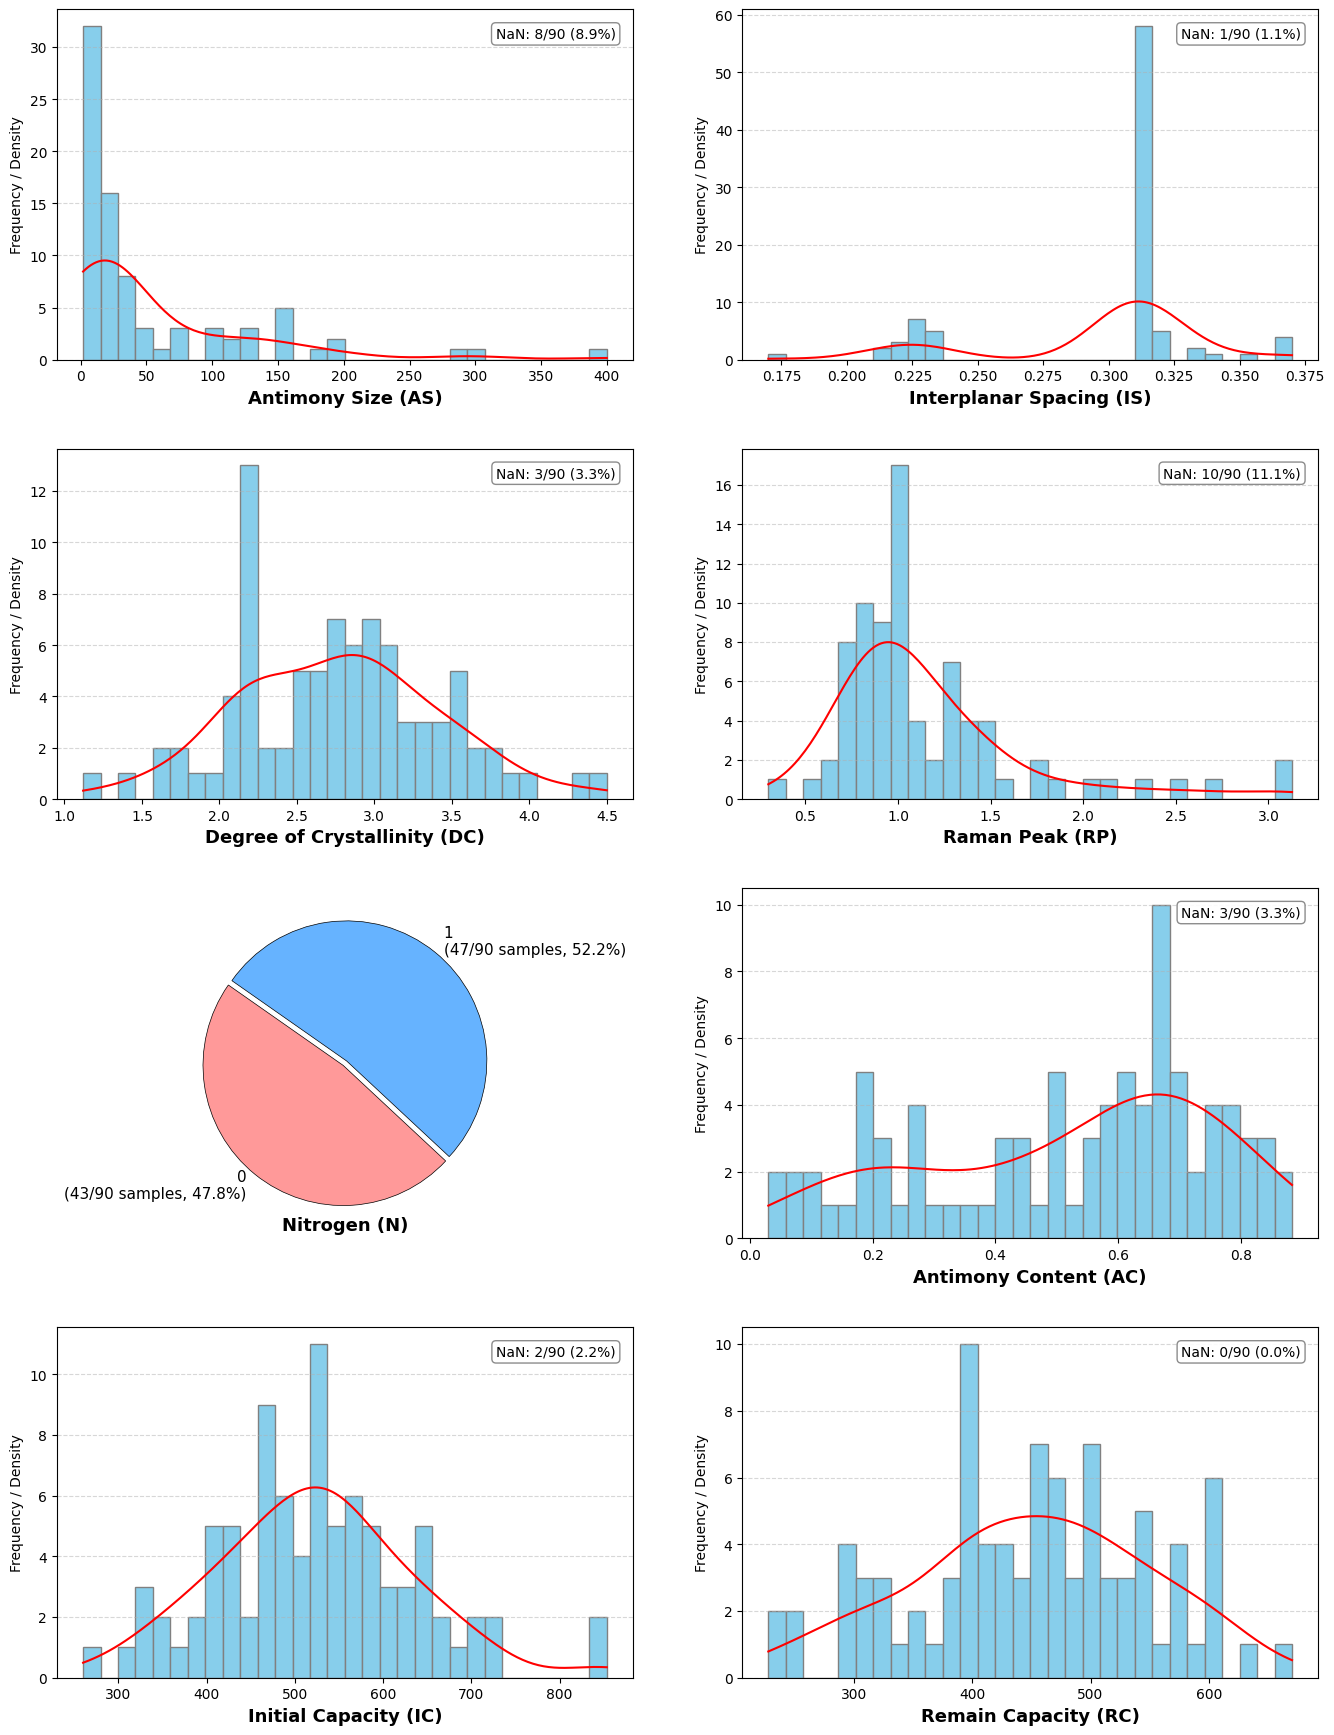

In [6]:
def visualize_distribution(series: pd.Series, ax=None):
    """
    Plots the distribution (histogram + KDE curve) for a feature,
    showing the percentage of missing values (NaN).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    col_name = full_name[series.name] + f' ({series.name})' if series.name else "Data"
    total_samples = len(series)
    nan_count = series.isna().sum()
    nan_percentage = (nan_count / total_samples) * 100
    data_clean = series.dropna()
    
    sns.histplot(data_clean, ax=ax, 
                 facecolor='skyblue', edgecolor='gray', alpha=0.6,
                 kde=True, color='red',
                 bins=30)

    stats_text = f"NaN: {nan_count}/{total_samples} ({nan_percentage:.1f}%)"
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    ax.set_xlabel(f'{col_name}', fontsize=13, weight='bold')
    ax.set_ylabel("Frequency / Density")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    return ax

def visualize_categories_pie(series, ax=None, color_map={0: '#ff9999', 1: '#66b3ff'}):
    """
    Plots a pie chart for categorical features, including NaNs.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    counts = series.value_counts(dropna=False).sort_index()
    total = len(series)
    labels = []
    colors = []
    nan_color = '#d3d3d3'
    default_color = '#99ff99'

    for idx, count in counts.items():
        pct = (count / total) * 100
        if pd.isna(idx):
            label_text = "NaN"
            c = nan_color
        else:
            label_text = str(int(idx))
            c = color_map.get(int(idx), default_color)
        
        labels.append(f"{label_text}\n({count}/{total} samples, {pct:.1f}%)")
        colors.append(c)

    ax.pie(counts, labels=labels, 
        colors=colors, startangle=145, 
        explode=[0.02] * len(counts),
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'black'},
        textprops={'fontsize': 11, 'color': 'black'})

    col_name = f'{full_name[series.name]} ({series.name})' if series.name else "Data"
    ax.set_title(f'{col_name}', fontsize=13, weight='bold', y=0)
    return ax

# Plot distributions for all features
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, col_name in enumerate(data.columns):
    if col_name == 'N':
        visualize_categories_pie(data[col_name], ax=axes[i])
    else:
        visualize_distribution(data[col_name], ax=axes[i])

plt.tight_layout(pad=3)
plt.show()

### 1.2.2. <a id='toc1_2_2_'></a>[Linear Correlation Analysis](#toc0_)

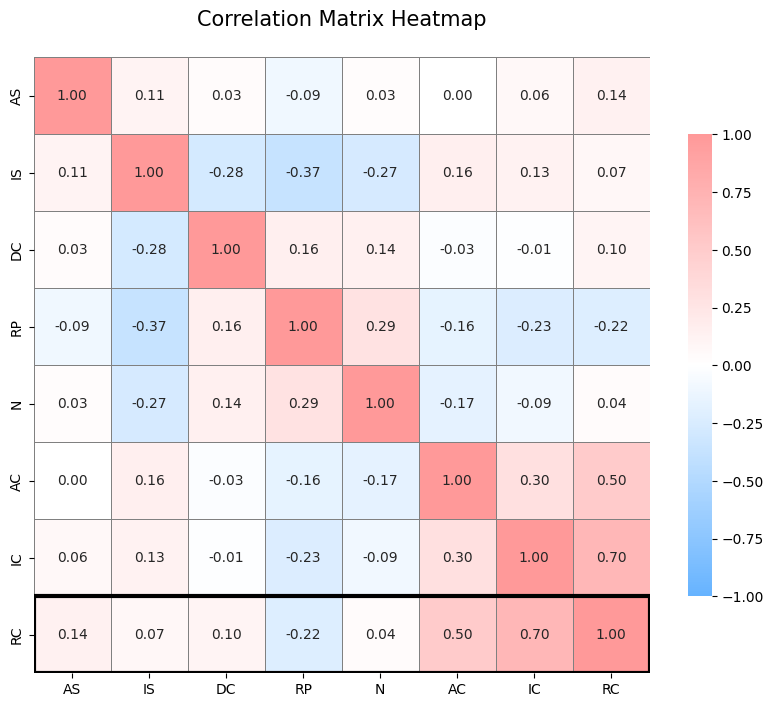

In [7]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

def draw_heatmap(df, ax=None):
    """
    Draws a correlation heatmap, highlighting the target variable (RC).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    corr_matrix = df.corr(numeric_only=True)
    colors = ['#66b3ff', '#ffffff', '#ff9999']
    custom_cmap = LinearSegmentedColormap.from_list('custom_blue_red', colors, N=256)

    rect = patches.Rectangle(
        (0, len(df.columns)-1), 
        width=len(df.columns), 
        height=1, 
        linewidth=3, 
        edgecolor='black', 
        facecolor='none'
    )

    sns.heatmap(
        corr_matrix, 
        annot=True,
        fmt=".2f",
        cmap=custom_cmap,
        vmin=-1, vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={"shrink": 0.75},
        ax=ax
    )
    ax.add_patch(rect)
    ax.set_title("Correlation Matrix Heatmap\n", fontsize=15)
    return ax

draw_heatmap(data)
plt.show()

In [8]:
# Finding which sample has the closest initial capacity to remaining capacity ratio of 1
idx = np.argmin(np.abs(data['IC'] / data['RC'] - 1))
print(f"Sample Index: {idx}")
data.iloc[idx]

Sample Index: 85


AS     20.00
IS      0.32
DC      2.93
RP      0.95
N       0.00
AC      0.78
IC    540.40
RC    540.50
Name: 85, dtype: float64

### 1.2.3. <a id='toc1_2_3_'></a>[Closer Look at Correlation and CEP Method](#toc0_)

In [39]:
from sklearn.cluster import KMeans

def visualize_correlation(feature, target, ax=None):
    """
    Plots scatter + regression line between feature and target,
    annotated with Pearson correlation coefficient (r) and p-value.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    df_temp = pd.DataFrame({'Target': target, 'Feature': feature}).dropna()
    if len(df_temp) < 2:
        ax.text(0.5, 0.5, "Not enough data", ha='center', va='center')
        return ax

    r, p = stats.pearsonr(df_temp['Target'], df_temp['Feature'])
    sns.regplot(x='Target', y='Feature', data=df_temp, ax=ax, 
                scatter_kws={'alpha': 0.6, 's': 30}, 
                line_kws={'color': 'red', 'linewidth': 2})

    stats_text = f"$r = {r:.2f}$\n$p = {p:.2e}$"
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    x_name = f'{full_name[target.name]} ({target.name})' if target.name else "Target"
    y_name = f'{full_name[feature.name]} ({feature.name})' if feature.name else "Feature"
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name, weight='bold', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.5)
    return ax

def visualize_target_by_category(category, target, ax=None):
    """
    Plots the target variable distribution split by a categorical variable.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
        
    cat_name = f"{full_name[category.name]} ({category.name})" if category.name else "Category"
    target_name = f"{full_name[target.name]} ({target.name})" if target.name else "Target"
    df_temp = pd.DataFrame({
        target_name: target,
        cat_name: category.fillna('NaN')
    })

    custom_palette = {0: '#ff9999', 1: '#66b3ff', 'NaN': 'gray'}
    sns.histplot(
        data=df_temp,
        x=target_name, 
        hue=cat_name, 
        multiple="stack", 
        kde=True,
        ax=ax,
        palette=custom_palette, 
        edgecolor=".3",
        linewidth=.5,
        bins=20
    )
    ax.set_xlabel(f"{target_name} depend on {cat_name}", fontsize=13)
    ax.set_ylabel("Number", weight='bold', fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    return ax

def visualize_cep_method(feature, target, cluster=4):
    """
    Displays two side-by-side plots for the CEP method. 
    """
    df_temp = pd.DataFrame({'Feature': feature, 'Target': target}).dropna()
    X_data = df_temp[['Feature', 'Target']].values 
    
    if len(df_temp) < cluster:
        raise ValueError("Not enough data to form clusters.")

    kmeans = KMeans(n_clusters=cluster, random_state=42)
    labels = kmeans.fit_predict(X_data)
    centroids = kmeans.cluster_centers_
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    feature_name = feature.name if hasattr(feature, 'name') else 'Feature'
    target_name = target.name if hasattr(target, 'name') else 'Target'

    # Left chart: Target = f(Feature)
    centroids_1 = centroids[centroids[:, 0].argsort()]
    cx_1, cy_1 = centroids_1[:, 0], centroids_1[:, 1]
    poly_func_1 = np.poly1d(np.polyfit(cx_1, cy_1, deg=2))
    
    ax1.scatter(df_temp['Feature'], df_temp['Target'], c=labels, cmap='viridis', alpha=0.6)
    ax1.scatter(cx_1, cy_1, color='red', marker='*', s=300, edgecolors='black')
    x_line_1 = np.linspace(df_temp['Feature'].min(), df_temp['Feature'].max(), 200)
    ax1.plot(x_line_1, poly_func_1(x_line_1), color='red', linestyle='--', linewidth=2)
    ax1.set_title(f'Original: {target_name} = f({feature_name})')
    ax1.set_xlabel(feature_name)
    ax1.set_ylabel(target_name)
    ax1.grid(True, linestyle=':', alpha=0.7)

    # Right chart: Feature = f(Target)
    centroids_2 = centroids[centroids[:, 1].argsort()]
    cx_2, cy_2 = centroids_2[:, 1], centroids_2[:, 0]
    poly_func_2 = np.poly1d(np.polyfit(cx_2, cy_2, deg=2))
    
    ax2.scatter(df_temp['Target'], df_temp['Feature'], c=labels, cmap='viridis', alpha=0.6)
    ax2.scatter(cx_2, cy_2, color='red', marker='*', s=300, edgecolors='black')
    x_line_2 = np.linspace(df_temp['Target'].min(), df_temp['Target'].max(), 200)
    ax2.plot(x_line_2, poly_func_2(x_line_2), color='red', linestyle='--', linewidth=2)
    ax2.set_title(f'Swapped Axes: {feature_name} = f({target_name})')
    ax2.set_xlabel(target_name)
    ax2.set_ylabel(feature_name)
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    return poly_func_1, poly_func_2

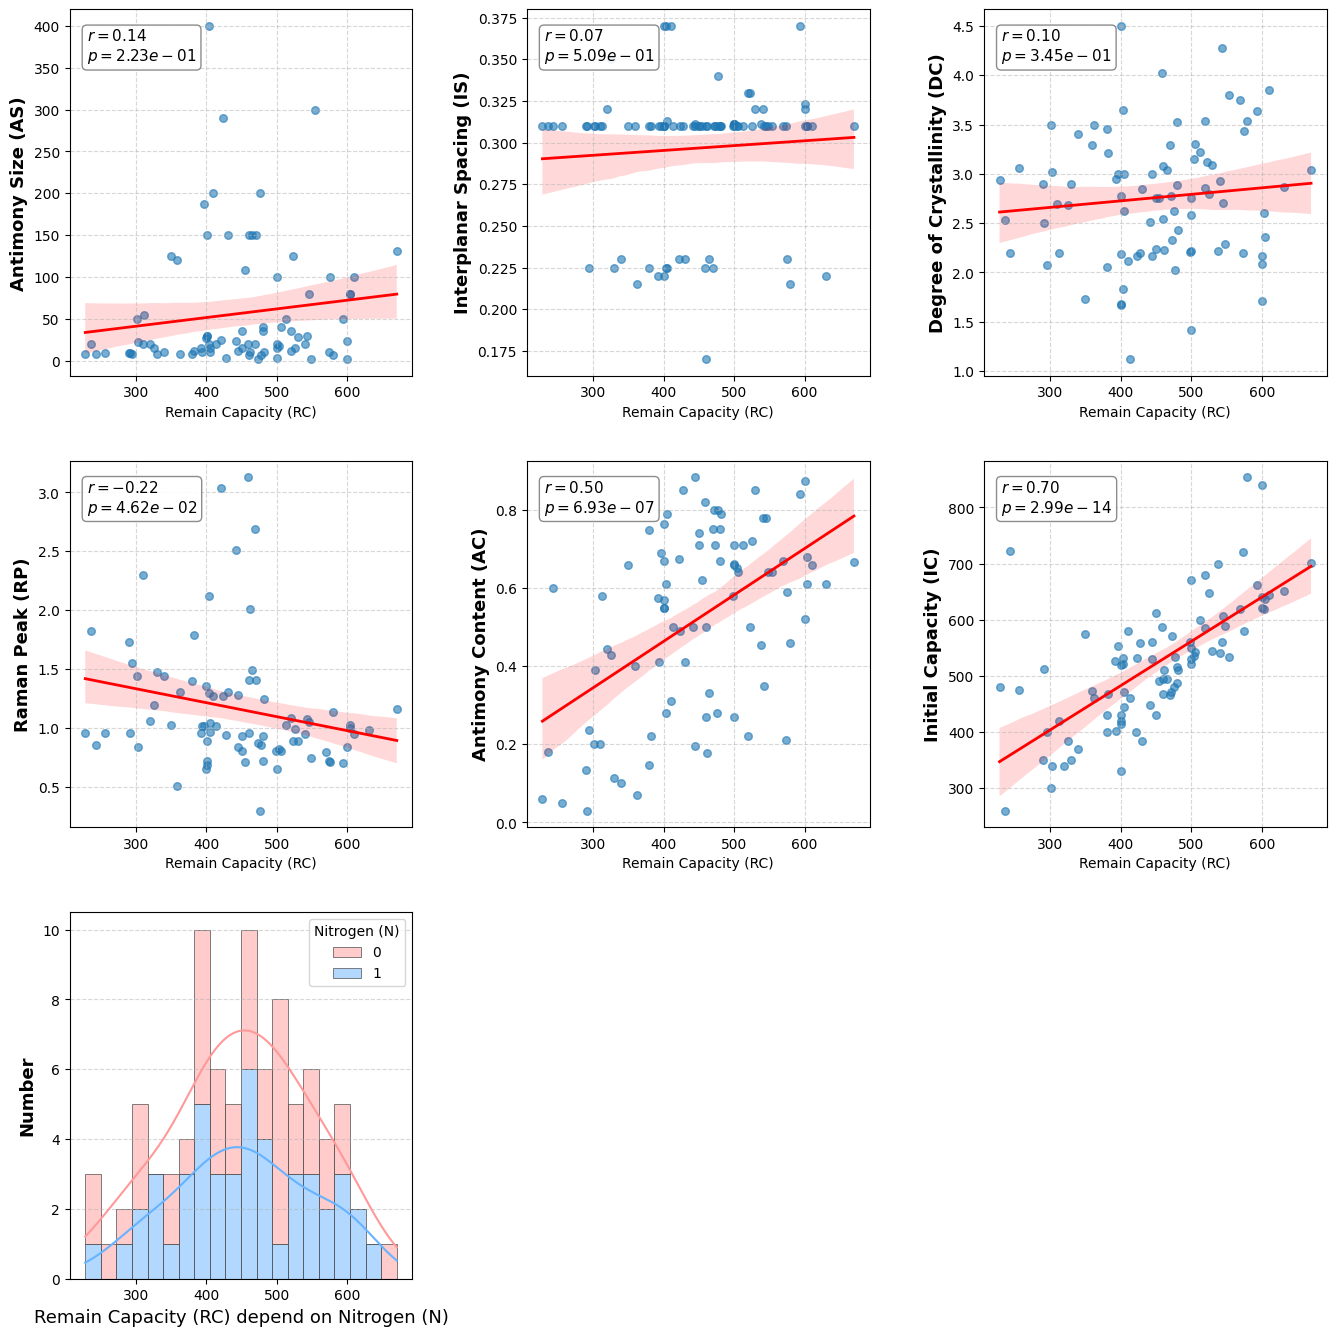

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 14))
axes = axes.flatten()
for i in range(7, 9): fig.delaxes(axes[i])

i = 0
visualize_target_by_category(category=data['N'], target=y, ax=axes[6])
for col_name in data.columns:
    if col_name not in [y.name, 'N']:
        visualize_correlation(feature=data[col_name], target=y, ax=axes[i])
        i += 1

plt.tight_layout(pad=3)
plt.show()

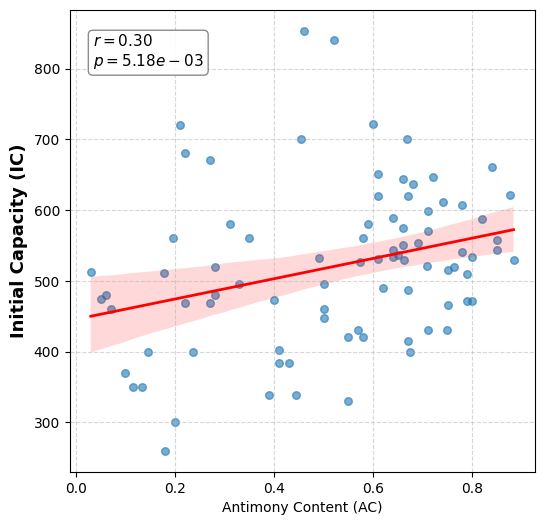

In [12]:
visualize_correlation(feature=data['IC'], target=data['AC'])
plt.show()

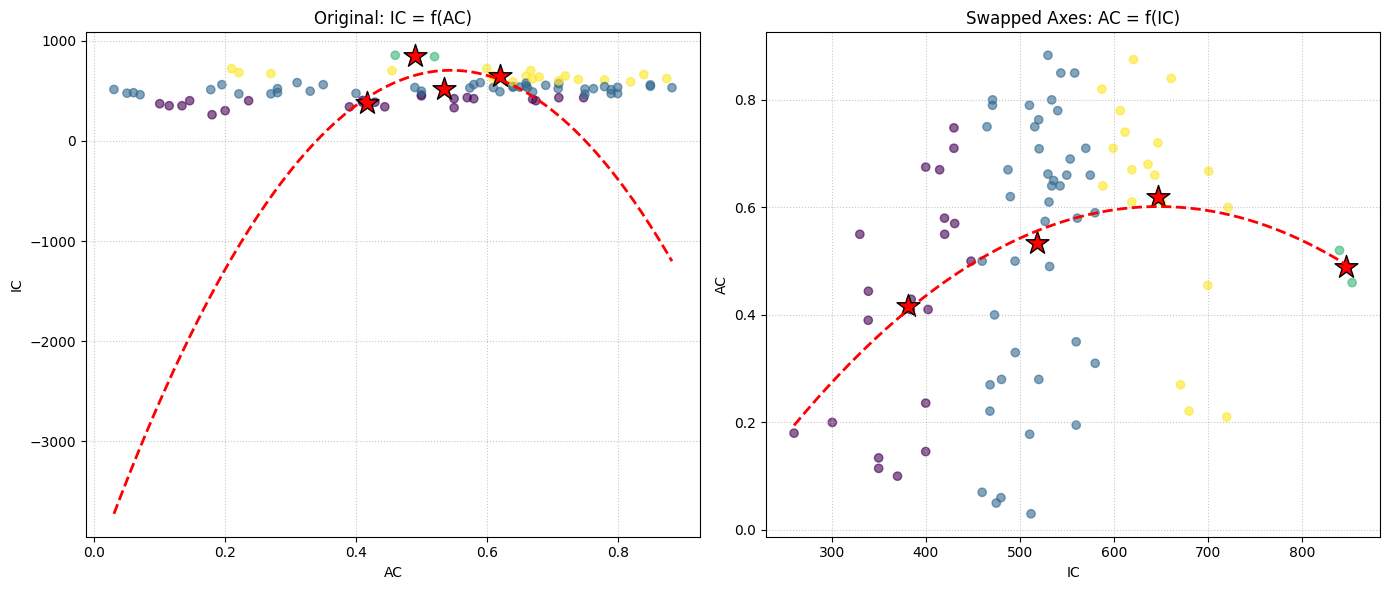

In [13]:
# Replicating Paper Fig S3: using 4 clusters (4-means) for CEP curve fitting
visualize_cep_method(feature=data['AC'], target=data['IC'], cluster=4)
plt.show()

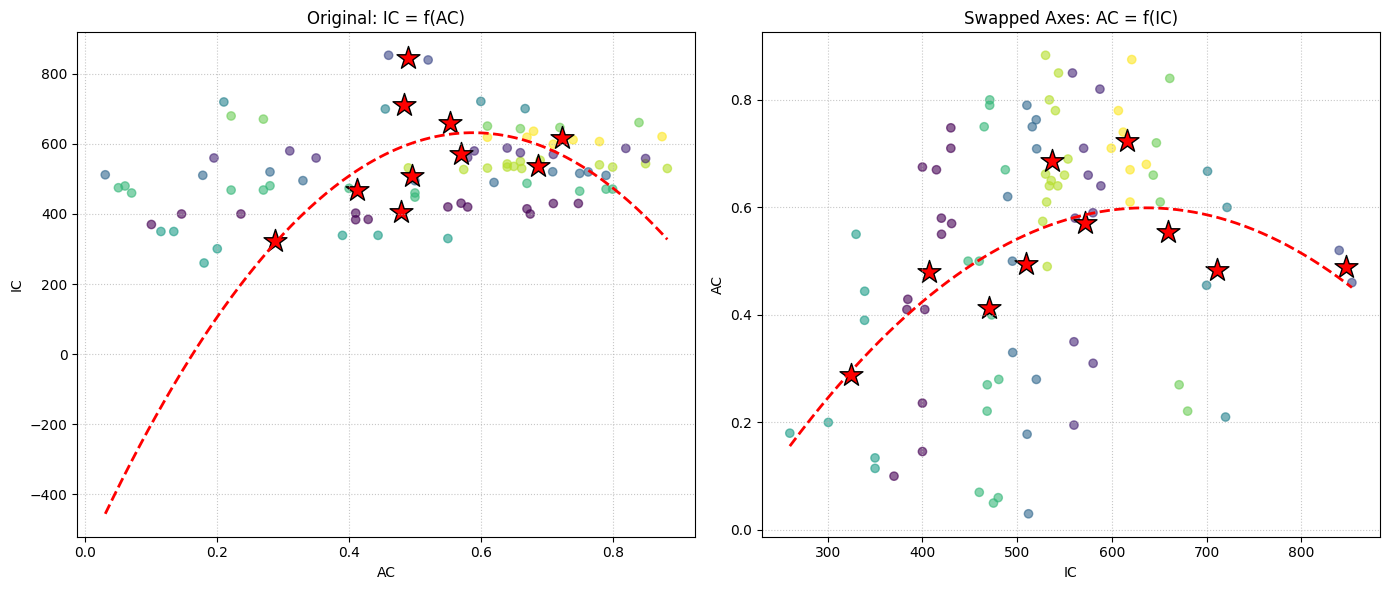

In [14]:
# Comparing with 10 clusters as done in the previous incorrect notebook
visualize_cep_method(feature=data['AC'], target=data['IC'], cluster=10)
plt.show()

# 2. <a id='toc2_'></a>[Preprocessing and Splitting](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Train-Test Split (Avoiding Leakage)](#toc0_)

To prevent **data leakage**, we first partition our 90 samples into training and testing sets. Imputers and scalers must be fitted **only on the training set** and used to transform both splits.

**Split configuration:**
- Train-Test Split Ratio: 80% train (72 samples), 20% test (18 samples).
- `random_state=10` is used to split the dataset in a way that matches the paper's distribution.
- K-Means for the CEP method is fit on the training split with `n_clusters=4` to fit the polynomial curve.

In [15]:
def feature_extraction_formulas(df_in):
    """
    Creates physics-based structural parameters from original features.
    """
    df_out = df_in.copy()
    epsilon = 1e-6
    df_out['(1 - AC)'] = 1 - df_out['AC']
    df_out['AC * AS'] = df_out['AC'] * df_out['AS']
    df_out['AC * AS^3'] = df_out['AC'] * (df_out['AS'] ** 3)
    df_out['AC / (1 - AC)'] = df_out['AC'] / (df_out['(1 - AC)'] + epsilon)
    df_out['DC * RP'] = df_out['DC'] * df_out['RP']
    df_out['DC / RP'] = df_out['DC'] / (df_out['RP'] + epsilon)
    df_out['(1 - AC) * DC'] = df_out['(1 - AC)'] * df_out['DC']
    df_out['(1 - AC) * RP / DC'] = df_out['(1 - AC)'] * (df_out['RP'] / (df_out['DC'] + epsilon))
    df_out['AC * AS * DC / RP'] = df_out['AC * AS'] * df_out['DC / RP']
    
    numerator = df_out['AC * AS^3']
    denominator = df_out['(1 - AC) * DC'] + epsilon
    df_out['(AC * AS^3) / ((1 - AC) * DC)'] = numerator / denominator
    df_out['AC * AS / IS'] = df_out['AC * AS'] / (df_out['IS'] + epsilon)
    df_out['AC / IS'] = df_out['AC'] / (df_out['IS'] + epsilon)
    df_out['IS / AS'] = df_out['IS'] / (df_out['AS'] + epsilon)
    df_out['AS^2 / IS'] = (df_out['AS'] ** 2) / (df_out['IS'] + epsilon)
    df_out['AC / AS'] = df_out['AC'] / (df_out['AS'] + epsilon)
    return df_out

In [16]:
def fit_cep_and_imputer(X_tr):
    """
    Fits K-Means CEP method and KNN Imputer using training data only.
    """
    # 1. Fit CEP K-Means curve
    valid_data = X_tr.dropna(subset=['AC', 'IC'])
    kmeans = KMeans(n_clusters=4, random_state=42)
    kmeans.fit(valid_data[['AC', 'IC']])
    centers = kmeans.cluster_centers_
    centers = centers[centers[:, 0].argsort()]
    poly_coeffs = np.polyfit(centers[:, 0], centers[:, 1], deg=2)
    trend_curve = np.poly1d(poly_coeffs)
    
    # Apply CEP trend to train set to fill missing IC values
    X_tr_cep = X_tr.copy()
    mask = X_tr_cep['IC'].isnull() & X_tr_cep['AC'].notnull()
    X_tr_cep.loc[mask, 'IC'] = trend_curve(X_tr_cep.loc[mask, 'AC'])
    
    # 2. Fit KNNImputer on the CEP-filled training data
    imputer = KNNImputer(n_neighbors=5)
    imputer.fit(X_tr_cep)
    return trend_curve, imputer

def transform_data(X_df, trend_curve, imputer):
    """
    Applies the fitted CEP curve and KNNImputer to any dataset.
    """
    X_cep = X_df.copy()
    mask = X_cep['IC'].isnull() & X_cep['AC'].notnull()
    X_cep.loc[mask, 'IC'] = trend_curve(X_cep.loc[mask, 'AC'])
    X_imputed = pd.DataFrame(imputer.transform(X_cep), columns=X_df.columns, index=X_df.index)
    return X_imputed

In [21]:
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2.2. Preprocessing & Capacity Estimation Polynomial (CEP) Method
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=18/90, random_state=10
)

# Fit preprocessors on training split only
trend_curve, imputer = fit_cep_and_imputer(X_train_raw)

# Impute training and testing splits separately
X_train = transform_data(X_train_raw, trend_curve, imputer)
X_test = transform_data(X_test_raw, trend_curve, imputer)

print("Fitted CEP Equation:")
print(f"IC = {trend_curve.coeffs[0]:.2f} * AC^2 + {trend_curve.coeffs[1]:.2f} * AC + {trend_curve.coeffs[2]:.2f}")

Fitted CEP Equation:
IC = -11837.96 * AC^2 + 13560.94 * AC + -3232.06


In [22]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Imputed Training Features:")
X_train.describe()

Imputed Training Features:


,AC,AS,RP,IS,N,IC,DC
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,0.531471,60.848528,1.190097,0.298656,0.486111,512.501826,2.745306
std,0.220120,76.371864,0.523291,0.039685,0.503315,211.076169,0.676209
min,0.030000,2.000000,0.510000,0.170000,0.000000,-993.385397,1.120000
25%,0.397500,11.825000,0.890000,0.310000,0.000000,460.000000,2.207500
50%,0.580000,24.500000,1.030000,0.310000,0.000000,532.880000,2.755000
75%,0.694750,82.215000,1.302500,0.310250,1.000000,591.532662,3.167500
max,0.875000,400.000000,3.127000,0.370000,1.000000,853.400000,4.500000


## 2.3. <a id='toc2_3_'></a>[Evaluation & K-Fold Training Wrappers](#toc0_)

In [23]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

def run_kfold_wrapper(X_tr, y_tr, k=10, model_trainer=None):
    """
    Runs 10-fold cross-validation on training data.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    models = []
    history = {
        'val_r2': [], 'val_rmse': [], 'val_mae': [],
        'train_r2': []
    }
    
    print(f"{'='*20}\nSTART K-FOLD (K={k})\n{'='*20}")
    
    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_tr, y_tr)):
        X_fold_train, X_fold_val = X_tr.iloc[train_index], X_tr.iloc[val_index]
        y_fold_train, y_fold_val = y_tr.iloc[train_index], y_tr.iloc[val_index]
        
        model = model_trainer(X_fold_train, y_fold_train)
        
        y_train_pred = model.predict(X_fold_train)
        y_val_pred = model.predict(X_fold_val)
        
        train_r2, _, _ = calculate_metrics(y_fold_train, y_train_pred)
        val_r2, val_rmse, val_mae = calculate_metrics(y_fold_val, y_val_pred)
        
        history['train_r2'].append(train_r2)
        history['val_r2'].append(val_r2)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        models.append(model)
        
        print(f"[Fold {fold_idx+1:02d}] Train R2: {train_r2:5.3f} | Val R2: {val_r2:5.3f} | Val RMSE: {val_rmse:3.1f} | Val MAE: {val_mae:3.1f}")
        
    print(f"\n{'-'*20} AVERAGE PERFORMANCE {'-'*20}")
    print(f"Average Val R2  : {np.mean(history['val_r2']):5.3f} (±{np.std(history['val_r2']):.3f})")
    print(f"Average Val RMSE: {np.mean(history['val_rmse']):4.2f}")
    print(f"Average Val MAE : {np.mean(history['val_mae']):4.2f}")
    print(f"{'='*60}")
    return models

def evaluate_on_test_set(models, X_te, y_te, permutation_repeats=10, random_state=42):
    """
    Evaluates models on test set and computes feature importance.
    """
    print(f"\n{'='*30} EVALUATION & PERMUTATION IMPORTANCE REPORT {'='*30}")
    df_preds = pd.DataFrame({'Actual': y_te.values}, index=y_te.index)
    metrics_list = []
    all_preds_array = []
    feature_names = X_te.columns.tolist()
    df_perm = pd.DataFrame(index=feature_names)
    
    for i, model in enumerate(models):
        col_name = f'Model_{i+1}'
        preds = model.predict(X_te)
        all_preds_array.append(preds)
        df_preds[col_name] = preds
        
        r2, rmse, mae = calculate_metrics(y_te, preds)
        metrics_list.append({'Model': col_name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
        
        perm_result = permutation_importance(
            model, X_te, y_te, n_repeats=permutation_repeats, random_state=random_state, n_jobs=-1, scoring='r2'
        )
        df_perm[col_name] = perm_result.importances_mean
        
    avg_preds = np.mean(all_preds_array, axis=0)
    df_preds['Ensemble_Avg'] = avg_preds
    ens_r2, ens_rmse, ens_mae = calculate_metrics(y_te, avg_preds)
    metrics_list.append({'Model': 'Ensemble_Avg', 'R2': ens_r2, 'RMSE': ens_rmse, 'MAE': ens_mae})
    
    if not df_perm.empty:
        df_perm['Average_Importance'] = df_perm.mean(axis=1)
        df_perm = df_perm.sort_values(by='Average_Importance', ascending=False)
        
    print("\n--- PERFORMANCE METRICS TABLE ---")
    print(pd.DataFrame(metrics_list).set_index('Model').round(4))
    print(f"\n{'='*80}")
    return df_preds, df_perm

## 2.4. <a id='toc2_4_'></a>[Optuna Tuning Wrapper](#toc0_)

In [24]:
import optuna

def run_optuna_tuning(X_tr, y_tr, search_ranges, objective_func, n_trials=50):
    """
    Optuna hyperparameter tuning wrapper.
    """
    study = optuna.create_study(direction='maximize')
    func = lambda trial: objective_func(trial, X_tr, y_tr, search_ranges)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study.optimize(func, n_trials=n_trials, show_progress_bar=True)
    
    print("\n" + "="*30)
    print("OPTIMIZED PARAMS")
    print(f"Best CV R2: {study.best_value:.4f}")
    print("Best parameters:")
    for key, value in study.best_params.items():
        print(f"  - {key}: {value}")
    print("="*30)
    return study.best_params

c:\Users\Yoga\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. <a id='toc3_'></a>[Model Training & Hyperparameter Tuning](#toc0_)

## 3.1. <a id='toc3_1_'></a>[Random Forest Regressor](#toc0_)

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from functools import partial

def objective_rf(trial, X, y, search_ranges):
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', *search_ranges['n_estimators']),
        'max_depth': trial.suggest_int('max_depth', *search_ranges['max_depth']),
        'min_samples_split': trial.suggest_int('min_samples_split', *search_ranges['min_samples_split']),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', *search_ranges['min_samples_leaf']),
        'max_features': trial.suggest_categorical('max_features', search_ranges['max_features']),
        'criterion': trial.suggest_categorical('criterion', search_ranges['criterion']),
        'random_state': search_ranges['random_state'],
        'n_jobs': search_ranges['n_jobs']
    }
    model = RandomForestRegressor(**rf_params)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    return val_r2_scores.mean()

def RandomForest_trainer(X_tr, y_tr, **kwargs):
    model = RandomForestRegressor(**kwargs)
    model.fit(X_tr, y_tr)
    return model

rf_search_range = {
    'n_estimators': (100, 500),
    'max_depth': (4, 10),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 10),
    'max_features': [None, "sqrt", "log2"],
    'criterion': ['squared_error', 'absolute_error'],
    'random_state': 42,
    'n_jobs': -1
}

best_rf_params = run_optuna_tuning(X_train_scaled, y_train, rf_search_range, objective_rf, n_trials=50)
best_rf_params['random_state'] = 42
best_rf_params['n_jobs'] = -1

tuned_rf_trainer = partial(RandomForest_trainer, **best_rf_params)
rf_models_tuned = run_kfold_wrapper(X_train_scaled, y_train, k=10, model_trainer=tuned_rf_trainer)

[I 2026-05-26 09:45:27,935] A new study created in memory with name: no-name-cb6f8e4f-034b-434e-a8af-dd030dbdae93
Best trial: 32. Best value: 0.17669: 100%|██████████| 50/50 [02:20<00:00,  2.81s/it] 



OPTIMIZED PARAMS
Best CV R2: 0.1767
Best parameters:
  - n_estimators: 288
  - max_depth: 10
  - min_samples_split: 9
  - min_samples_leaf: 10
  - max_features: None
  - criterion: absolute_error
START K-FOLD (K=10)
[Fold 01] Train R2: 0.494 | Val R2: 0.526 | Val RMSE: 94.5 | Val MAE: 78.1
[Fold 02] Train R2: 0.521 | Val R2: 0.619 | Val RMSE: 49.9 | Val MAE: 43.3
[Fold 03] Train R2: 0.548 | Val R2: 0.412 | Val RMSE: 50.5 | Val MAE: 40.6
[Fold 04] Train R2: 0.526 | Val R2: 0.717 | Val RMSE: 39.2 | Val MAE: 33.9
[Fold 05] Train R2: 0.531 | Val R2: 0.722 | Val RMSE: 38.1 | Val MAE: 34.5
[Fold 06] Train R2: 0.684 | Val R2: -3.398 | Val RMSE: 146.3 | Val MAE: 115.2
[Fold 07] Train R2: 0.536 | Val R2: 0.402 | Val RMSE: 54.1 | Val MAE: 46.3
[Fold 08] Train R2: 0.513 | Val R2: 0.612 | Val RMSE: 66.9 | Val MAE: 60.0
[Fold 09] Train R2: 0.516 | Val R2: 0.588 | Val RMSE: 67.2 | Val MAE: 55.2
[Fold 10] Train R2: 0.540 | Val R2: 0.567 | Val RMSE: 45.6 | Val MAE: 42.1

-------------------- AVERAGE 

In [26]:
rf_preds_df, rf_feature_importance_df = evaluate_on_test_set(rf_models_tuned, X_test_scaled, y_test)
rf_feature_importance_df.head()


============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2     RMSE      MAE
Model                                 
Model_1       0.5917  68.6457  52.4294
Model_2       0.6384  64.6021  51.9367
Model_3       0.6602  62.6275  50.6150
Model_4       0.6674  61.9566  47.6546
Model_5       0.6609  62.5605  49.9313
Model_6       0.6281  65.5117  50.4791
Model_7       0.6378  64.6573  51.0050
Model_8       0.6252  65.7724  51.1001
Model_9       0.6236  65.9141  52.1063
Model_10      0.6693  61.7825  49.6750
Ensemble_Avg  0.6456  63.9555  50.4804



,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Average_Importance
IC,0.652755,6.530458e-01,0.745380,0.713761,0.707895,0.730433,0.784291,0.662431,7.494471e-01,0.713374,0.711281
AC,0.040376,6.049734e-02,0.052700,0.091669,0.068581,0.049073,0.043910,0.069214,2.383494e-02,0.059922,0.055978
AS,0.001942,1.656441e-02,0.007607,0.002112,0.006466,0.004401,0.006798,0.009465,2.244067e-03,0.011263,0.006886
DC,0.000616,5.116288e-03,0.001126,0.000981,-0.000659,-0.000077,0.002068,0.001640,2.535366e-03,0.000588,0.001393
N,0.000016,-2.301010e-07,0.000592,0.000414,0.000067,-0.000209,0.000097,0.000774,5.370986e-07,0.000019,0.000177


## 3.2. <a id='toc3_2_'></a>[XGBoost Regressor](#toc0_)

In [ ]:
import xgboost as xgb

def objective_xgb(trial, X, y, search_ranges):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', *search_ranges['n_estimators']),
        'learning_rate': trial.suggest_float('learning_rate', *search_ranges['learning_rate'], log=True),
        'max_depth': trial.suggest_int('max_depth', *search_ranges['max_depth']),
        'subsample': trial.suggest_float('subsample', *search_ranges['subsample']),
        'colsample_bytree': trial.suggest_float('colsample_bytree', *search_ranges['colsample_bytree']),
        'reg_alpha': trial.suggest_float('reg_alpha', *search_ranges['reg_alpha']),
        'reg_lambda': trial.suggest_float('reg_lambda', *search_ranges['reg_lambda']),
        'objective': trial.suggest_categorical('objective', search_ranges['objective']),
        'random_state': search_ranges['random_state'],
        'n_jobs': search_ranges['n_jobs']
    }
    model = xgb.XGBRegressor(**params)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    return val_r2_scores.mean()

def XGBoost_trainer(X_tr, y_tr, **kwargs):
    model = xgb.XGBRegressor(**kwargs)
    model.fit(X_tr, y_tr)
    return model

xgb_search_range = {
    'n_estimators': (50, 500),
    'learning_rate': (0.01, 0.2),
    'max_depth': (3, 8),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0),
    'reg_alpha': (0.0, 2.0),
    'reg_lambda': (0.0, 2.0),
    'objective': ['reg:squarederror'],
    'random_state': 42,
    'n_jobs': -1
}

best_xgb_params = run_optuna_tuning(X_train_scaled, y_train, xgb_search_range, objective_xgb, n_trials=50)
best_xgb_params['random_state'] = 42
best_xgb_params['n_jobs'] = -1

tuned_xgb_trainer = partial(XGBoost_trainer, **best_xgb_params)
xgb_models_tuned = run_kfold_wrapper(X_train_scaled, y_train, k=10, model_trainer=tuned_xgb_trainer)

In [ ]:
xgb_preds_df, xgb_feature_importance_df = evaluate_on_test_set(xgb_models_tuned, X_test_scaled, y_test)
xgb_feature_importance_df.head()

## 3.3. <a id='toc3_3_'></a>[Support Vector Regressor (SVR)](#toc0_)

In [ ]:
from sklearn.svm import SVR

def objective_svr(trial, X, y, search_ranges):
    params = {
        'kernel': trial.suggest_categorical('kernel', search_ranges['kernel']),
        'C': trial.suggest_float('C', *search_ranges['C'], log=True),
        'gamma': trial.suggest_categorical('gamma', search_ranges['gamma']),
        'epsilon': trial.suggest_float('epsilon', *search_ranges['epsilon'], log=True)
    }
    model = SVR(**params)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    return val_r2_scores.mean()

def SVR_trainer(X_tr, y_tr, **kwargs):
    model = SVR(**kwargs)
    model.fit(X_tr, y_tr)
    return model

svr_search_range = {
    'kernel': ['rbf', 'linear'],
    'C': (10.0, 5000.0),
    'gamma': ['scale', 'auto'],
    'epsilon': (0.01, 1.0)
}

best_svr_params = run_optuna_tuning(X_train_scaled, y_train, svr_search_range, objective_svr, n_trials=50)
SVR_with_params = partial(SVR_trainer, **best_svr_params)
svr_models_tuned = run_kfold_wrapper(X_train_scaled, y_train, k=10, model_trainer=SVR_with_params)

In [ ]:
svr_preds_df, svr_feature_importance_df = evaluate_on_test_set(svr_models_tuned, X_test_scaled, y_test)
svr_feature_importance_df.head()

## 3.4. <a id='toc3_4_'></a>[AdaBoost Regressor](#toc0_)

In [44]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

def objective_ada(trial, X, y, search_ranges):
    base_max_depth = trial.suggest_int('max_depth', *search_ranges['max_depth'])
    params = {
        'n_estimators': trial.suggest_int('n_estimators', *search_ranges['n_estimators']),
        'learning_rate': trial.suggest_float('learning_rate', *search_ranges['learning_rate'], log=True),
        'loss': trial.suggest_categorical('loss', search_ranges['loss']),
        'random_state': search_ranges['random_state']
    }
    base_tree = DecisionTreeRegressor(max_depth=base_max_depth, random_state=42)
    model = AdaBoostRegressor(estimator=base_tree, **params)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    return val_r2_scores.mean()

def AdaBoost_trainer(X_tr, y_tr, **kwargs):
    base_tree = DecisionTreeRegressor(max_depth=kwargs.get('max_depth'), random_state=42)
    kwargs_copy = kwargs.copy()
    kwargs_copy.pop('max_depth', None)
    model = AdaBoostRegressor(estimator=base_tree, **kwargs_copy)
    model.fit(X_tr, y_tr)
    return model

ada_search_range = {
    'max_depth': (3, 8),
    'n_estimators': (50, 300),
    'learning_rate': (0.01, 1.0),
    'loss': ['linear', 'square', 'exponential'],
    'random_state': 42
}

best_ada_params = run_optuna_tuning(X_train_scaled, y_train, ada_search_range, objective_ada, n_trials=50)
Ada_with_params = partial(AdaBoost_trainer, **best_ada_params)
ada_models_tuned = run_kfold_wrapper(X_train_scaled, y_train, k=10, model_trainer=Ada_with_params)

Best trial: 9. Best value: -0.0478619: 100%|██████████| 50/50 [02:06<00:00,  2.54s/it]



OPTIMIZED PARAMS
Best CV R2: -0.0479
Best parameters:
  - max_depth: 3
  - n_estimators: 82
  - learning_rate: 0.12479587749057805
  - loss: linear
START K-FOLD (K=10)
[Fold 01] Train R2: 0.860 | Val R2: 0.663 | Val RMSE: 79.7 | Val MAE: 71.3
[Fold 02] Train R2: 0.858 | Val R2: -1.266 | Val RMSE: 121.6 | Val MAE: 86.0
[Fold 03] Train R2: 0.870 | Val R2: 0.520 | Val RMSE: 45.7 | Val MAE: 38.3
[Fold 04] Train R2: 0.864 | Val R2: 0.560 | Val RMSE: 48.8 | Val MAE: 40.4
[Fold 05] Train R2: 0.856 | Val R2: 0.199 | Val RMSE: 64.6 | Val MAE: 48.6
[Fold 06] Train R2: 0.900 | Val R2: -3.747 | Val RMSE: 152.0 | Val MAE: 111.5
[Fold 07] Train R2: 0.874 | Val R2: 0.191 | Val RMSE: 62.9 | Val MAE: 54.1
[Fold 08] Train R2: 0.853 | Val R2: 0.569 | Val RMSE: 70.5 | Val MAE: 62.3
[Fold 09] Train R2: 0.858 | Val R2: 0.387 | Val RMSE: 81.9 | Val MAE: 63.6
[Fold 10] Train R2: 0.866 | Val R2: 0.110 | Val RMSE: 65.4 | Val MAE: 57.4

-------------------- AVERAGE PERFORMANCE --------------------
Average Val R

In [46]:
ada_preds_df, ada_feature_importance_df = evaluate_on_test_set(ada_models_tuned, X_test_scaled, y_test)
ada_feature_importance_df.head()


============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2     RMSE      MAE
Model                                 
Model_1       0.8007  47.9641  41.3202
Model_2       0.8363  43.4711  35.6374
Model_3       0.8035  47.6277  40.9864
Model_4       0.8248  44.9641  39.6867
Model_5       0.8128  46.4860  40.9197
Model_6       0.8221  45.3136  39.1791
Model_7       0.8069  47.2083  39.5891
Model_8       0.8277  44.5992  37.9523
Model_9       0.8142  46.3068  39.5606
Model_10      0.8310  44.1607  37.9645
Ensemble_Avg  0.8291  44.4126  37.6138



,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Average_Importance
IC,0.716298,0.676956,0.742317,0.756405,0.603913,0.777054,0.731304,0.735767,0.769439,0.684467,0.719392
AC,0.163336,0.260206,0.189965,0.256767,0.331289,0.284780,0.279211,0.210950,0.179360,0.220230,0.237609
AS,0.039906,0.050904,0.039282,0.021874,0.004593,0.003150,0.017707,0.027874,0.040207,0.021139,0.026664
IS,0.005365,0.005643,0.001190,0.002809,0.003042,0.003509,0.000916,0.000001,-0.001656,0.005301,0.002612
DC,-0.007255,0.011246,-0.000558,-0.001183,-0.002094,0.001970,0.007868,0.003344,0.004791,0.006320,0.002445


# 4. <a id='toc4_'></a>[Model Analysis](#toc0_)

## 4.1. <a id='toc4_1_'></a>[SHAP Analysis](#toc0_)

In [31]:
import shap

def calculate_ensemble_shap(models, X, y, scaler):
    """
    Computes average SHAP values across all K-fold models.
    """
    print(f"Calculating SHAP values for {len(models)} models...")
    X_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)
    
    total_shap_values = np.zeros(X_scaled.shape)
    total_base_values = np.zeros(X_scaled.shape[0])
    total_predictions = np.zeros(X_scaled.shape[0])
    
    try:
        for model in models:
            explainer = shap.TreeExplainer(model)
            shap_obj = explainer(X_scaled)
            total_shap_values += np.array(shap_obj.values)
            
            base_val = shap_obj.base_values
            if np.isscalar(base_val):
                base_val_array = np.full(X_scaled.shape[0], base_val)
            else:
                base_val_array = np.array(base_val).flatten()
                if base_val_array.size == 1:
                    base_val_array = np.full(X_scaled.shape[0], base_val_array[0])
            
            total_base_values += base_val_array
            total_predictions += np.array(model.predict(X_scaled)).flatten()
            
    except Exception as e:
        print("Falling back to KernelExplainer...")
        total_shap_values = np.zeros(X_scaled.shape)
        total_base_values = np.zeros(X_scaled.shape[0])
        total_predictions = np.zeros(X_scaled.shape[0])
        for model in models:
            predict_fn = lambda x: model.predict(pd.DataFrame(x, columns=X_scaled.columns))
            explainer = shap.KernelExplainer(predict_fn, X_scaled)
            shap_vals = np.array(explainer.shap_values(X_scaled))
            total_shap_values += shap_vals
            
            expected_val = explainer.expected_value
            if np.isscalar(expected_val):
                base_val_array = np.full(X_scaled.shape[0], expected_val)
            else:
                base_val_array = np.array(expected_val).flatten()
                if base_val_array.size == 1:
                    base_val_array = np.full(X_scaled.shape[0], base_val_array[0])
            total_base_values += base_val_array
            total_predictions += np.array(model.predict(X_scaled)).flatten()
            
    avg_shap_values = total_shap_values / len(models)
    avg_base_values = total_base_values / len(models)
    avg_predictions = total_predictions / len(models)
    
    base_value_float = float(avg_base_values[0])
    df_shap = pd.DataFrame(avg_shap_values, columns=X.columns, index=X.index)
    df_shap.insert(0, 'Actual_Value', y)
    df_shap.insert(1, 'Ensemble_Predicted', avg_predictions)
    return base_value_float, df_shap

In [32]:
# Run SHAP on the tuned AdaBoost model (the best model)
base_value, df_shap = calculate_ensemble_shap(ada_models_tuned, X_train, y_train, scaler)
features = X_train.columns
shap_values_matrix = df_shap[features].values

print(f"\nBase Value (Expected Value): {base_value:.4f}")
df_shap.head()

Calculating SHAP values for 10 models...
Falling back to KernelExplainer...


100%|██████████| 72/72 [00:04<00:00, 14.80it/s]


Base Value (Expected Value): 454.2897


,Actual_Value,Ensemble_Predicted,AC,AS,RP,IS,N,IC,DC
39,529.6,498.802817,7.785739,3.807291,1.553190,0.619702,0.644453,23.137949,6.964831
50,500.0,550.642587,-6.142577,4.593511,-0.280652,-0.576593,-1.343579,97.946355,2.156459
6,469.5,441.493692,16.126759,1.154298,3.001080,0.685671,0.688091,-37.631169,3.179299
71,350.0,454.537075,6.374579,-1.349492,0.093698,-0.407119,-0.546112,11.196791,-15.114932
56,302.7,339.124003,-12.357787,-1.133443,-0.171477,-0.243008,-0.853495,-101.507907,1.101459


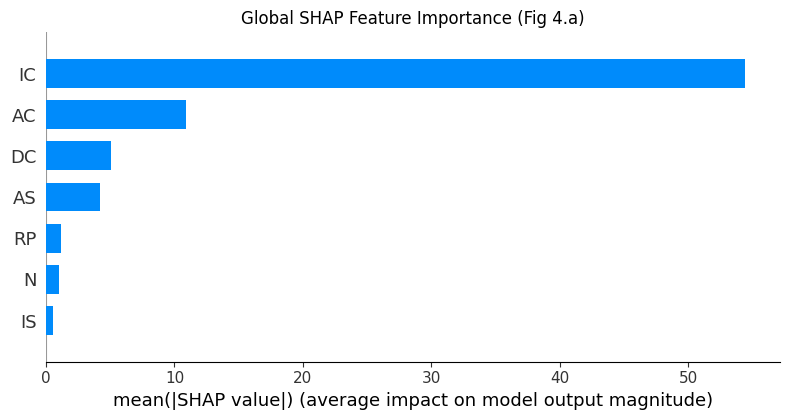

In [33]:
plt.title("Global SHAP Feature Importance (Fig 4.a)")
shap.summary_plot(shap_values_matrix, features=features, plot_type="bar", show=True)

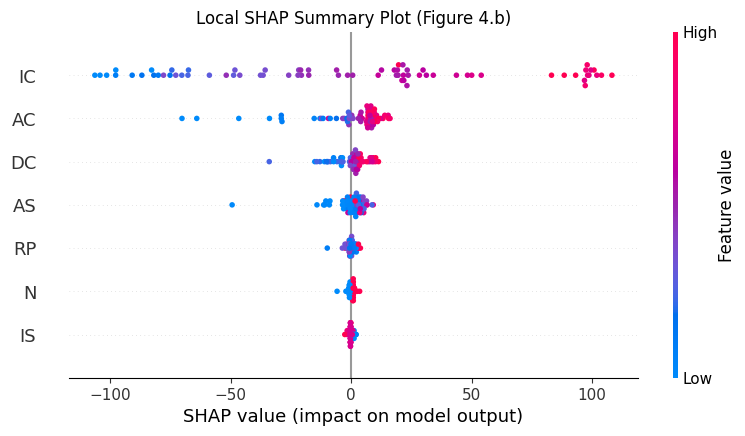

In [34]:
shap.summary_plot(shap_values_matrix, features=X_train, show=False)
plt.title("Local SHAP Summary Plot (Figure 4.b)")
plt.show()

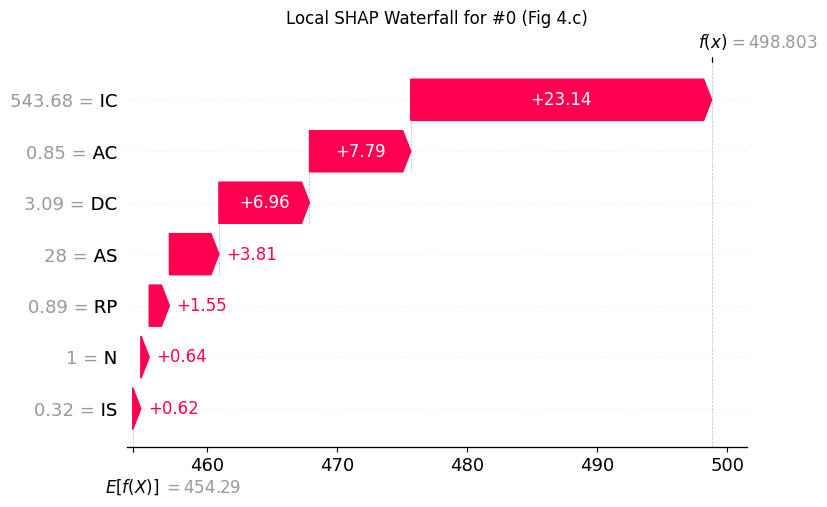

In [35]:
sample_idx = 0
explanation = shap.Explanation(
    values=shap_values_matrix[sample_idx], 
    base_values=base_value, 
    data=X_train.iloc[sample_idx].values, 
    feature_names=features.tolist()
)
plt.title(f"Local SHAP Waterfall for #{sample_idx} (Fig 4.c)")
shap.plots.waterfall(explanation)

## 4.2. <a id='toc4_2_'></a>[Generalization Testing on Fe@C Composites](#toc0_)

In [36]:
def generalization_test_pipeline(file_path, models, scaler, trend_curve, imputer):
    """
    Generalization pipeline for evaluating model on a completely new material (e.g. Fe@C).
    """
    print(f"\n{'='*50}")
    print(f"STARTING GENERALIZATION PIPELINE FOR: {file_path}")
    print(f"{'='*50}")

    df_new = pd.read_csv(file_path)
    if "DOI" in df_new.columns:
        df_new = df_new.drop(columns=["DOI"])
        
    X_new = df_new[['AC', 'AS', 'RP', 'IS', 'N', 'IC', 'DC']]
    y_new = df_new['RC']

    # Apply the fitted CEP curve and KNN Imputer
    X_new_imputed = transform_data(X_new, trend_curve, imputer)

    # Standardize the features
    X_new_scaled = pd.DataFrame(scaler.transform(X_new_imputed), columns=X_new.columns, index=X_new.index)

    # Predict
    df_preds, df_perm = evaluate_on_test_set(models=models, X_te=X_new_scaled, y_te=y_new)
    
    # Calculate Loss Rate (MAPE)
    df_preds['Loss_Rate(%)'] = (abs(df_preds['Actual'] - df_preds['Ensemble_Avg']) / df_preds['Actual']) * 100
    print(f"\nAverage Loss Rate on Fe@C: {df_preds['Loss_Rate(%)'].mean():.2f}%")
    
    return df_preds, df_perm

In [37]:
# Test the generalization capability of the AdaBoost Ensemble on Fe@C
fe_preds_df, fe_perm_df = generalization_test_pipeline(
    file_path='./input/Fe@C.csv', 
    models=ada_models_tuned,  
    scaler=scaler,
    trend_curve=trend_curve,
    imputer=imputer
)
display(fe_preds_df.head())


STARTING GENERALIZATION PIPELINE FOR: ./input/Fe@C.csv

============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2     RMSE      MAE
Model                                 
Model_1       0.6916  30.4219  24.4843
Model_2       0.5387  37.2076  35.7976
Model_3       0.6135  34.0575  31.3693
Model_4       0.7918  24.9941  23.1828
Model_5       0.7651  26.5497  22.1832
Model_6       0.7316  28.3840  26.9004
Model_7       0.7520  27.2814  24.7779
Model_8       0.6520  32.3166  26.1472
Model_9       0.7169  29.1471  26.0693
Model_10      0.6264  33.4865  33.0624
Ensemble_Avg  0.7278  28.5822  25.1749


Average Loss Rate on Fe@C: 5.30%


,Actual,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Ensemble_Avg,Loss_Rate(%)
0,400.0,390.433333,370.527273,381.708333,377.037500,378.083333,385.620000,386.466667,382.900000,379.000000,371.171429,380.294787,4.926303
1,457.8,436.773333,429.312500,431.800000,439.662500,438.620000,435.630000,431.600000,435.918182,434.505556,427.060000,434.088207,5.179509
2,510.0,455.106250,456.770000,456.493750,471.740909,465.728000,474.192857,467.184211,452.155556,462.464103,467.825926,462.966156,9.222322
3,545.0,532.550000,513.000000,572.679167,558.372222,548.364286,580.244444,561.562500,552.762500,557.446667,575.507143,555.248893,1.880531


## 4.3. <a id='toc4_3_'></a>[Material Screening & Sweet Spot Discovery (Exhaustive Method)](#toc0_)

We now perform the **Exhaustive Screening** of virtual Sb@C composites, as described in the paper. We create a grid of material parameters, interpolate `IC` using the CEP polynomial, predict cycle capacity (`RC`) using our AdaBoost ensemble model, and plot a contour map of the capacity space to locate the structural design "sweet spot".

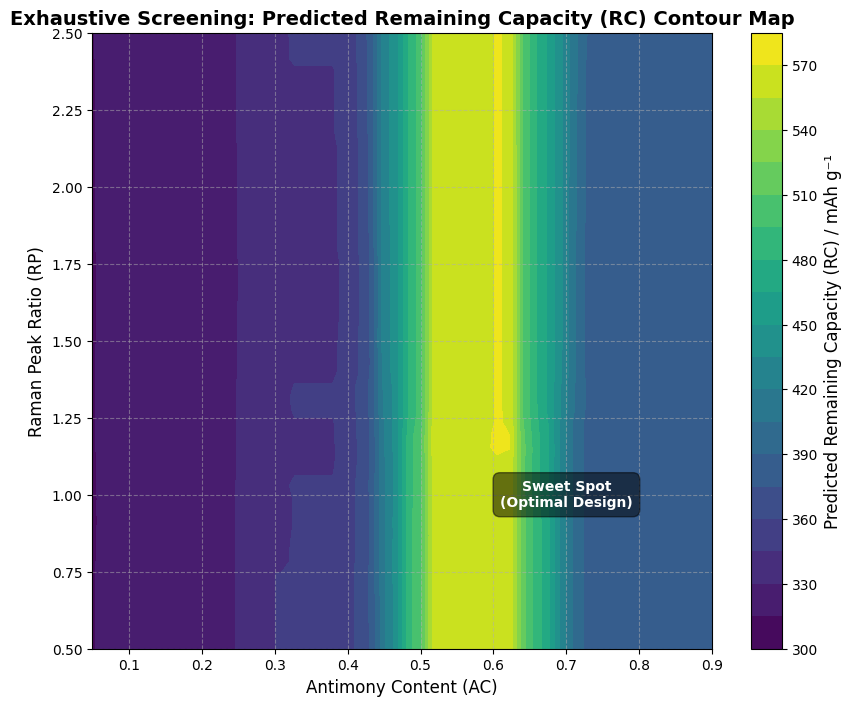

In [38]:
# 1. Create a grid of artificial structural parameters
ac_values = np.linspace(0.05, 0.90, 50)
rp_values = np.linspace(0.5, 2.5, 50)

ac_grid, rp_grid = np.meshgrid(ac_values, rp_values)
ac_flat = ac_grid.flatten()
rp_flat = rp_grid.flatten()

# Use mean values of original training features for fixed features
mean_vals = X_train.mean()

df_virtual = pd.DataFrame({
    'AC': ac_flat,
    'AS': np.full_like(ac_flat, mean_vals['AS']),
    'RP': rp_flat,
    'IS': np.full_like(ac_flat, mean_vals['IS']),
    'N': np.full_like(ac_flat, 0),  # Default to no nitrogen doping
    'IC': np.zeros_like(ac_flat),   # Will be filled by CEP
    'DC': np.full_like(ac_flat, mean_vals['DC'])
})

# 2. Calculate Virtual Initial Capacity using the fitted CEP curve
df_virtual['IC'] = trend_curve(df_virtual['AC'])

# 3. Standardize features using the original scaler
df_virtual_scaled = pd.DataFrame(scaler.transform(df_virtual), columns=df_virtual.columns)

# 4. Predict Remaining Capacity (RC) using the tuned AdaBoost ensemble
all_preds = []
for model in ada_models_tuned:
    all_preds.append(model.predict(df_virtual_scaled))
avg_rc = np.mean(all_preds, axis=0)

# Reshape predictions back to grid shape
rc_grid = avg_rc.reshape(ac_grid.shape)

# 5. Plot Contour Map
plt.figure(figsize=(10, 8))
contour = plt.contourf(ac_grid, rp_grid, rc_grid, levels=20, cmap='viridis')
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Remaining Capacity (RC) / mAh g⁻¹', fontsize=12)

plt.title('Exhaustive Screening: Predicted Remaining Capacity (RC) Contour Map', fontsize=14, fontweight='bold')
plt.xlabel('Antimony Content (AC)', fontsize=12)
plt.ylabel('Raman Peak Ratio (RP)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate the optimal region (sweet spot: high AC (~0.7) and low/moderate RP)
plt.text(0.70, 1.0, 'Sweet Spot\n(Optimal Design)', color='white', weight='bold',
         ha='center', va='center', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.5'))

plt.show()